In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gget
from tqdm import tqdm
from scipy.stats import ttest_ind
import os
import networkx as nx

import anndata as an
import scanpy as sc
import scvi

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
# load tfs so I got 'em
fpath = "../../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:5]

['ZNF354C', 'KLF12', 'ZNF143', 'ZIC2', 'ZNF274']

# Load data

In [3]:
### %%time
dpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/"
alpha = 0.01

clusters = ["C1", "C2", "C3", "C4", "C5"]

df_list = []

for c in clusters:
    fpath = f"{dpath}{c}/output/consensus_network_ncol_.txt"
    df = pd.read_csv(fpath, sep='\t')
    df = df.drop(columns=['source.symbol', 'target.symbol'])
    df['cluster'] = c
    df['sig'] = (df['p-value'] <= alpha)
    df_list.append(df)

df = pd.concat(df_list)
df['pair'] = df['source'] + " → " + df['target']
print(f"{df.shape=}")
print(df.head().to_string())

df.shape=(1044554, 10)
  source   target      MI  pearson  spearman   slope  p-value cluster    sig            pair
0   AATF    ACSL4  0.1007   0.1194    0.1096  0.2190   0.0005      C1   True    AATF → ACSL4
1   AATF  ADAMTS1  0.0917   0.1336    0.1242  0.9153   0.0001      C1   True  AATF → ADAMTS1
2   AATF    ADAT1  0.1066   0.1291    0.1187  0.1188   0.0002      C1   True    AATF → ADAT1
3   AATF  ADIPOR1  0.1037   0.1732    0.1417  0.2654   0.0000      C1   True  AATF → ADIPOR1
4   AATF   ANP32E  0.0888   0.0598    0.0978  0.0922   0.0842      C1  False   AATF → ANP32E


# TF Recipe

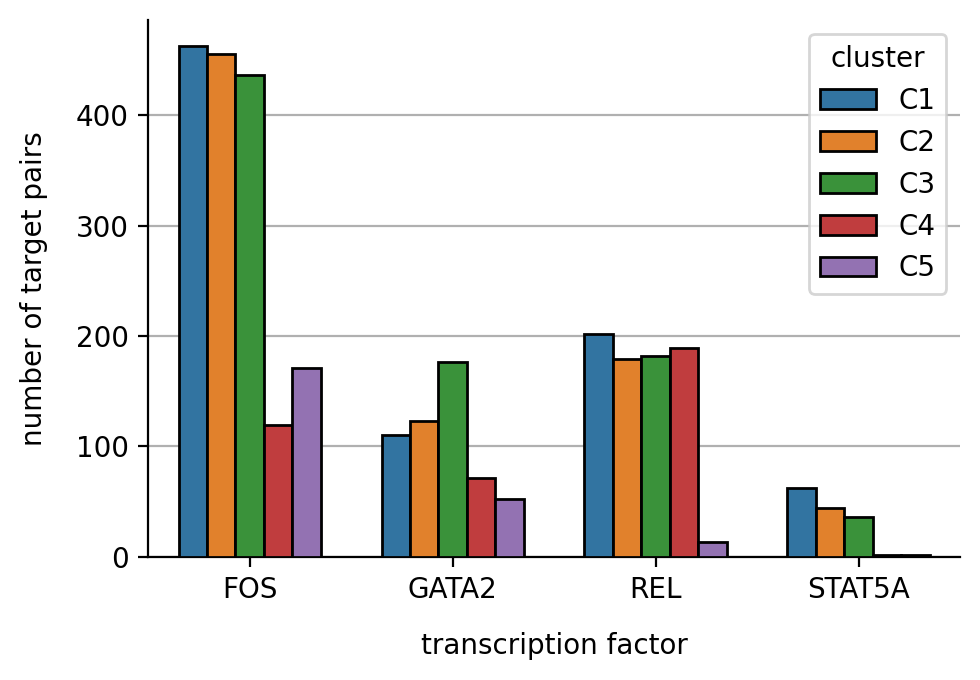

In [4]:
# Prep data
tf_recipe = ['GATA2', 'REL', 'STAT5A', 'FOS']
pdf = df[df['source'].isin(tf_recipe)].copy()
pdf = pdf[pdf['sig']]

pdf = (
    pdf.groupby(['cluster', 'source'])['target']
    .count()
    .reset_index(name='n_pairs')
)

# Set figure parameters
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (5, 3.5)

# Plot
ax = sns.barplot(
    data=pdf,
    x='source',
    y='n_pairs',
    hue='cluster',
    edgecolor='k',
    zorder=4,
    width=0.7,
)

# Labeling
ax.set_xlabel("transcription factor", labelpad=10)
ax.set_ylabel("number of target pairs", labelpad=10)
ax.yaxis.grid(True, zorder=1)
# Draw legend last with higher zorder
legend = ax.legend(title="cluster", frameon=True)
legend.set_zorder(3)
sns.despine()

# Optional: Tighter layout
plt.tight_layout()
plt.show()


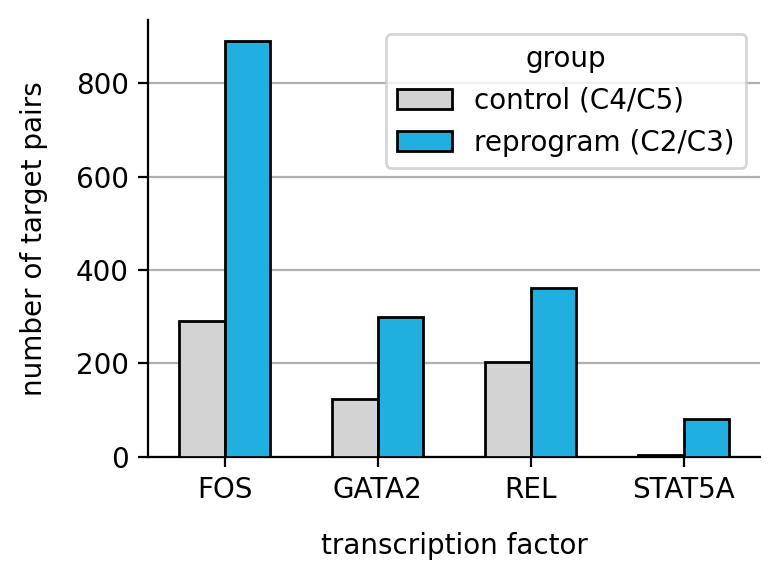

In [5]:
# Prep data
tf_recipe = ['GATA2', 'REL', 'STAT5A', 'FOS']
pdf = df[df['source'].isin(tf_recipe)].copy()
pdf = pdf[pdf['sig']]

# Map clusters to new group labels
cluster_map = {
    'C2': 'reprogram (C2/C3)',
    'C3': 'reprogram (C2/C3)',
    'C4': 'control (C4/C5)',
    'C5': 'control (C4/C5)'
}
pdf['group'] = pdf['cluster'].map(cluster_map)

# Drop rows not in the map (e.g., C1)
pdf = pdf[~pdf['group'].isna()]

# Group and count
pdf = (
    pdf.groupby(['group', 'source'])['target']
    .count()
    .reset_index(name='n_pairs')
)

# Plot setup
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (4, 3)

# Plot
ax = sns.barplot(
    data=pdf,
    x='source',
    y='n_pairs',
    hue='group',
    edgecolor='k',
    zorder=4,
    width=0.6,
    palette=['lightgrey', 'deepskyblue'],
)

# Labeling
ax.set_xlabel("transcription factor", labelpad=10)
ax.set_ylabel("number of target pairs", labelpad=10)
ax.yaxis.grid(True, zorder=1)

# Legend in front of grid
legend = ax.legend(title="group", frameon=True)
legend.set_zorder(3)

sns.despine()
plt.tight_layout()
plt.show()


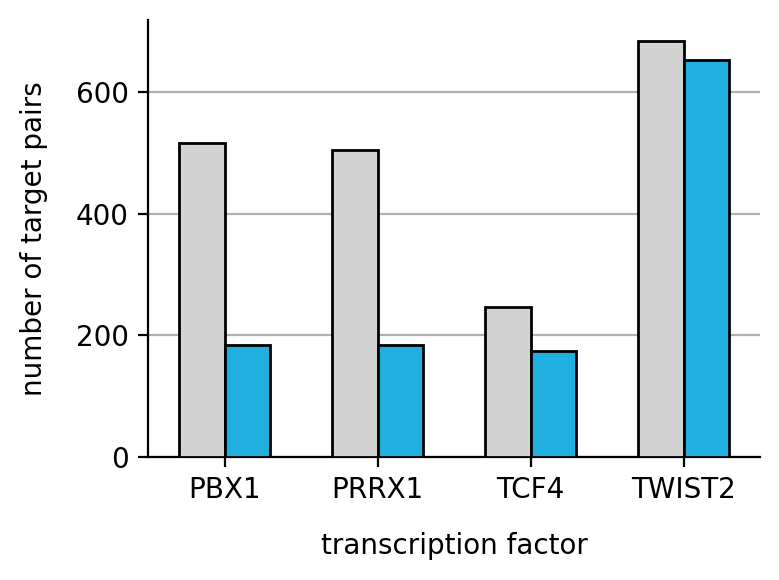

In [31]:
# Prep data
tf_recipe = ['PRRX1', 'TWIST2', 'PBX1', 'TCF4']
pdf = df[df['source'].isin(tf_recipe)].copy()
pdf = pdf[pdf['sig']]

# Map clusters to new group labels
cluster_map = {
    'C2': 'reprogram (C2/C3)',
    'C3': 'reprogram (C2/C3)',
    'C4': 'control (C4/C5)',
    'C5': 'control (C4/C5)'
}
pdf['group'] = pdf['cluster'].map(cluster_map)

# Drop rows not in the map (e.g., C1)
pdf = pdf[~pdf['group'].isna()]

# Group and count
pdf = (
    pdf.groupby(['group', 'source'])['target']
    .count()
    .reset_index(name='n_pairs')
)

# Plot setup
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (4, 3)

# Plot
ax = sns.barplot(
    data=pdf,
    x='source',
    y='n_pairs',
    hue='group',
    edgecolor='k',
    zorder=4,
    width=0.6,
    palette=['lightgrey', 'deepskyblue'],
)

# Labeling
ax.set_xlabel("transcription factor", labelpad=10)
ax.set_ylabel("number of target pairs", labelpad=10)
ax.yaxis.grid(True, zorder=1)

# Legend in front of grid
legend = ax.legend(title="group", frameon=True)
legend.set_zorder(3)
legend.remove()

sns.despine()
plt.tight_layout()
plt.show()


# Marker TFs

In [6]:
fpath = "../../../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
print(mdf.head().to_string(index=False))

gene_name         cell_type  is_tf  source    category
   TSPAN8 endothelial_cells  False panglao endothelial
     KLK1 endothelial_cells  False panglao endothelial
   RNASE1 endothelial_cells  False panglao endothelial
      LUM endothelial_cells  False panglao endothelial
      LOX endothelial_cells  False panglao endothelial


pdf.shape=(534979, 11)
('panglao', 'endothelial') plot_df.shape=(40, 3)


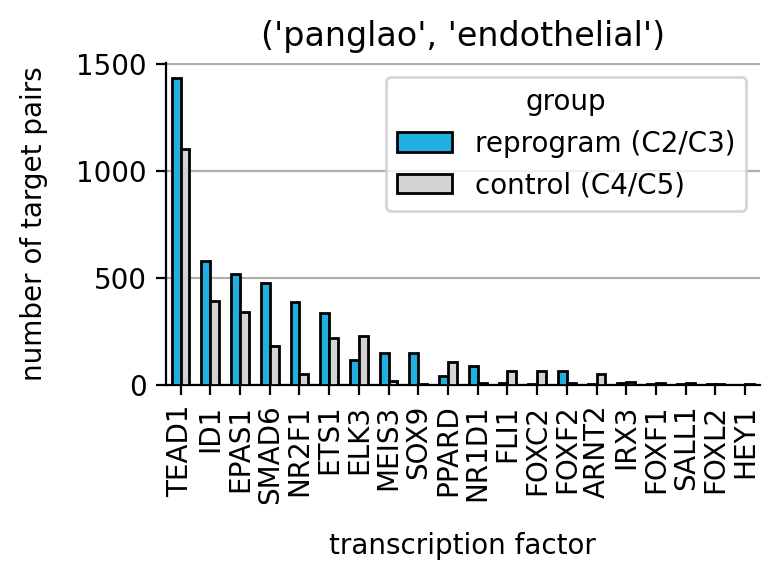

('panglao', 'fibroblast') plot_df.shape=(40, 3)


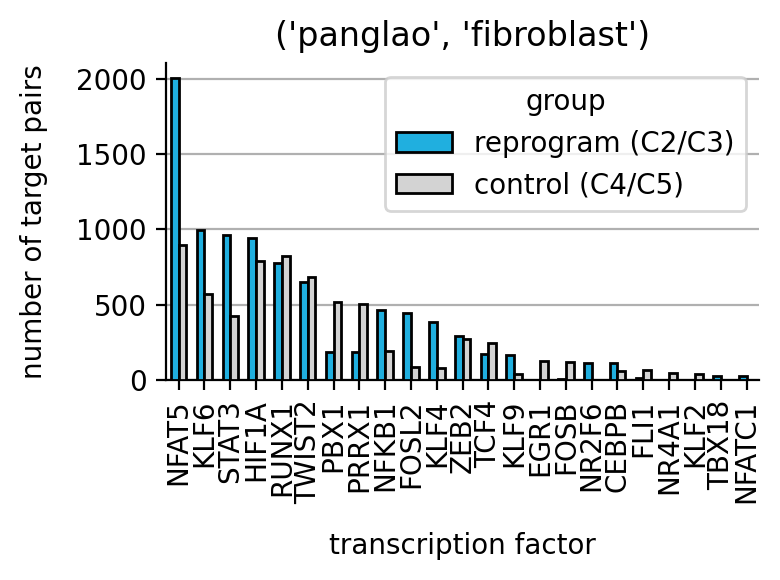

('panglao', 'hematopoietic') plot_df.shape=(40, 3)


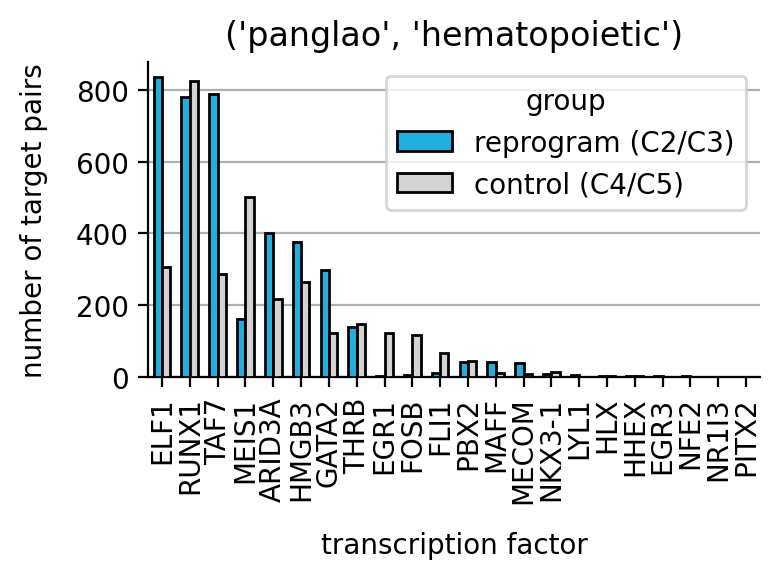

('tabula', 'endothelial') plot_df.shape=(34, 3)


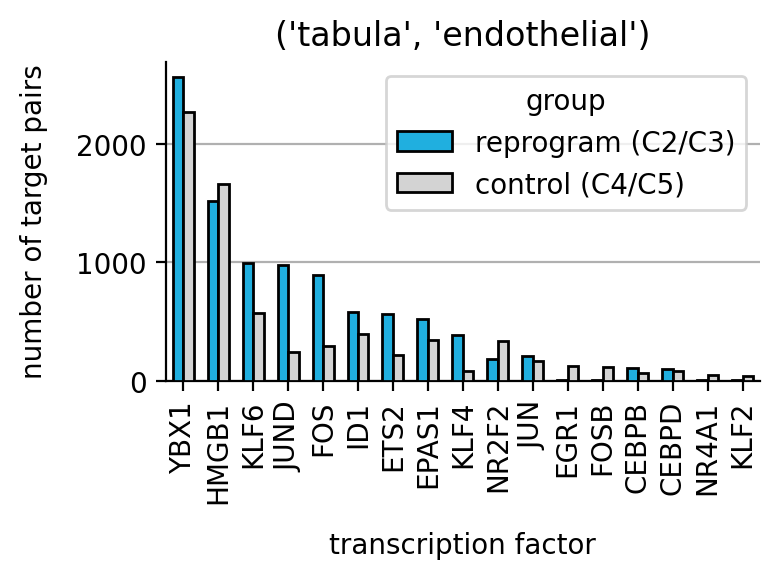

('tabula', 'fibroblast') plot_df.shape=(35, 3)


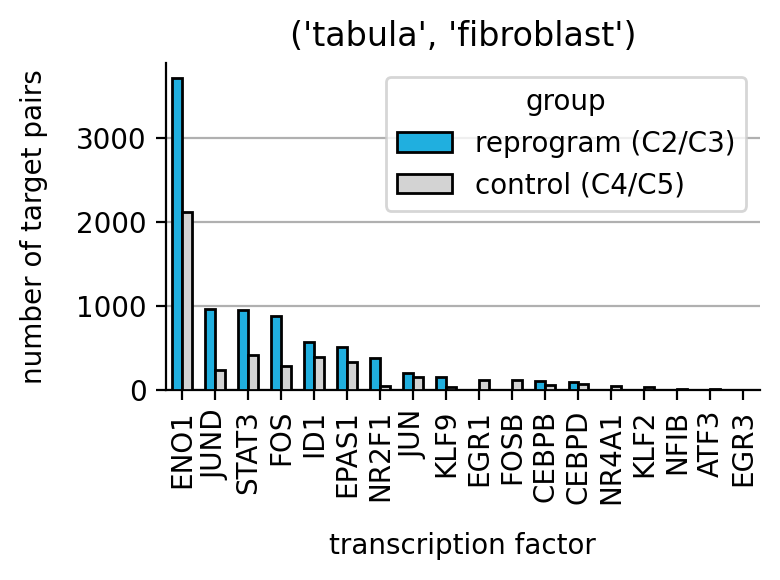

('tabula', 'hematopoietic') plot_df.shape=(10, 3)


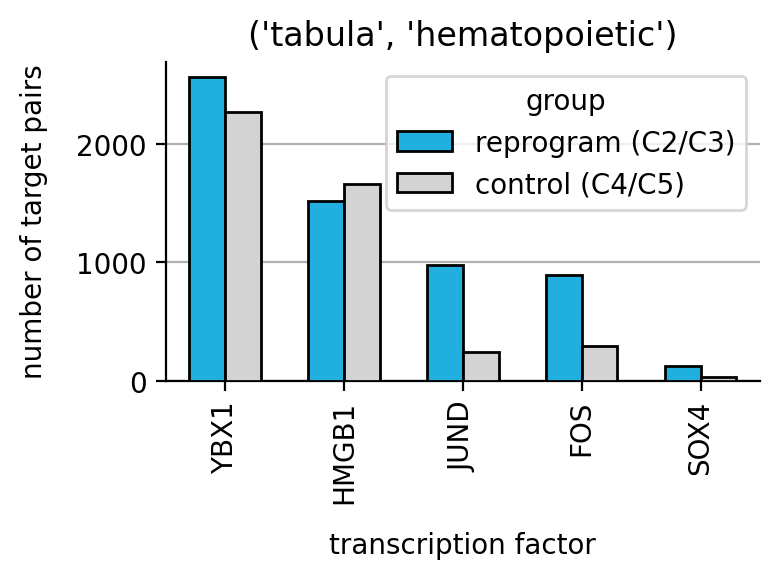

In [7]:

pdf = df.copy()
pdf = pdf[pdf['sig']]

# Map clusters to new group labels
cluster_map = {
    'C2': 'reprogram (C2/C3)',
    'C3': 'reprogram (C2/C3)',
    'C4': 'control (C4/C5)',
    'C5': 'control (C4/C5)'
}
pdf['group'] = pdf['cluster'].map(cluster_map)

# Drop rows not in the map (e.g., C1)
pdf = pdf[~pdf['group'].isna()]
print(f"{pdf.shape=}")

for group_name, group in mdf[mdf['is_tf']].groupby(['source', 'category']):

    # filter interactions
    gene_list = group['gene_name'].unique()

    # only consider cell type TFs
    plot_df = pdf[pdf['source'].isin(gene_list)]

    # Group and count
    plot_df = (
        plot_df.groupby(['group', 'source'])['target']
        .count()
        .reset_index(name='n_pairs')
    )

    top_n = 20  # or your threshold
    plot_df = (
        plot_df
        .sort_values('n_pairs', ascending=False)
        .groupby('group', group_keys=False)
        .head(top_n)
    )

    print(f"{group_name} {plot_df.shape=}")

    ax = sns.barplot(
        data=plot_df,
        x='source',
        y='n_pairs',
        hue='group',
        edgecolor='k',
        zorder=4,
        width=0.6,
        palette=['deepskyblue', 'lightgrey'],
    )

    # Labeling
    ax.set_xlabel("transcription factor", labelpad=10)
    ax.set_ylabel("number of target pairs", labelpad=10)
    ax.yaxis.grid(True, zorder=1)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(group_name)
    
    # Legend in front of grid
    legend = ax.legend(title="group", frameon=True)
    legend.set_zorder(3)
    
    sns.despine()
    plt.tight_layout()
    plt.show()



# MI Distribution by Cluster

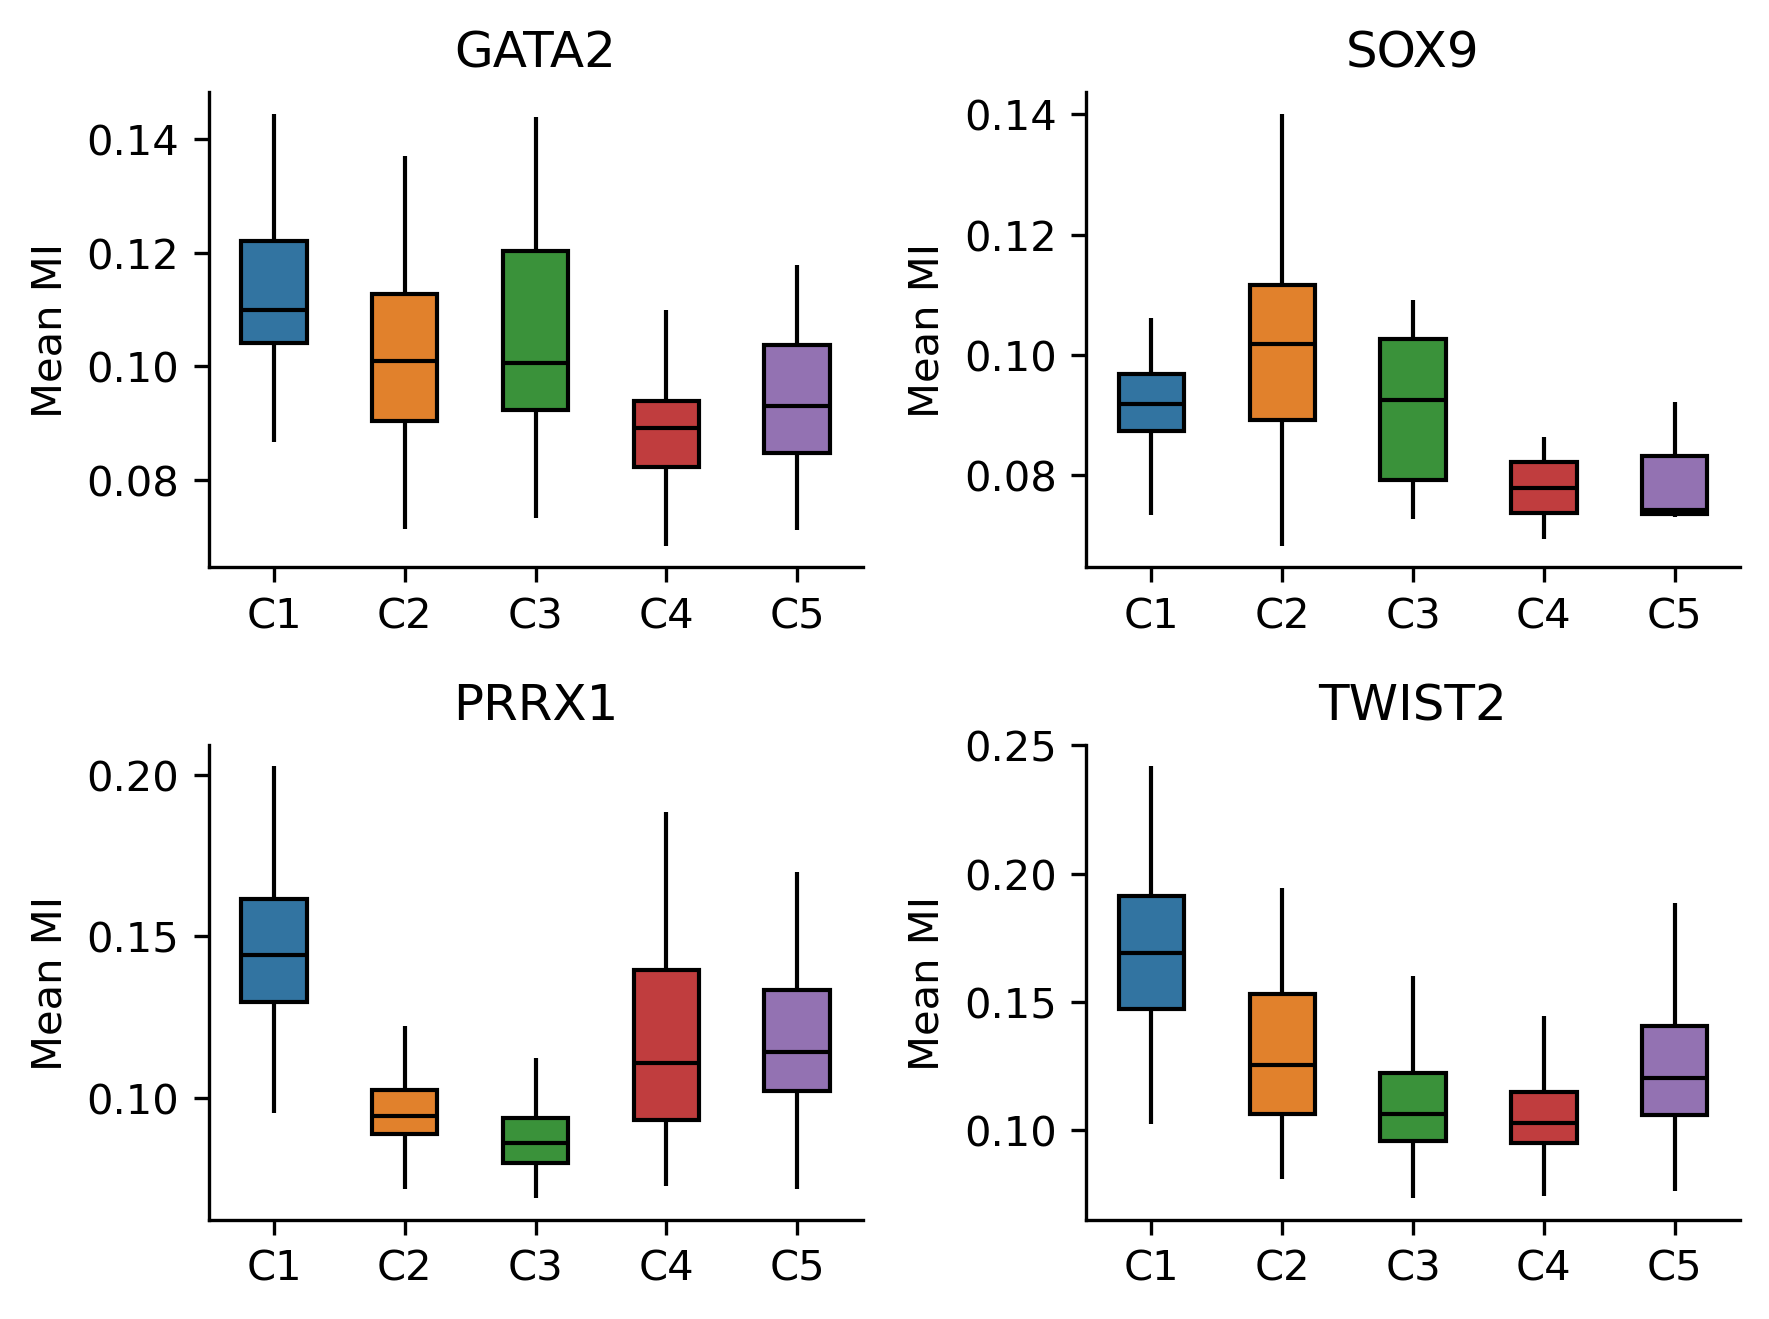

In [8]:
queries = ['GATA2', 'SOX9', 'PRRX1', 'TWIST2',]
fig, axes = plt.subplots(2, 2, figsize=(6, 4.5), dpi=300)

for ax, query in zip(axes.flat, queries):
    pdf = df[df['source'] == query].copy()
    pdf = pdf[pdf['sig']]

    sns.boxplot(
        data=pdf,
        x='cluster',
        y='MI',
        hue='cluster',
        ax=ax,
        showfliers=False,
        linecolor='k',
        width=0.5,
        linewidth=1,
        capprops={'lw': 0},
    )

    ax.set_title(query)
    ax.set_xlabel("")
    ax.set_ylabel("Mean MI")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Highest MI per cluster

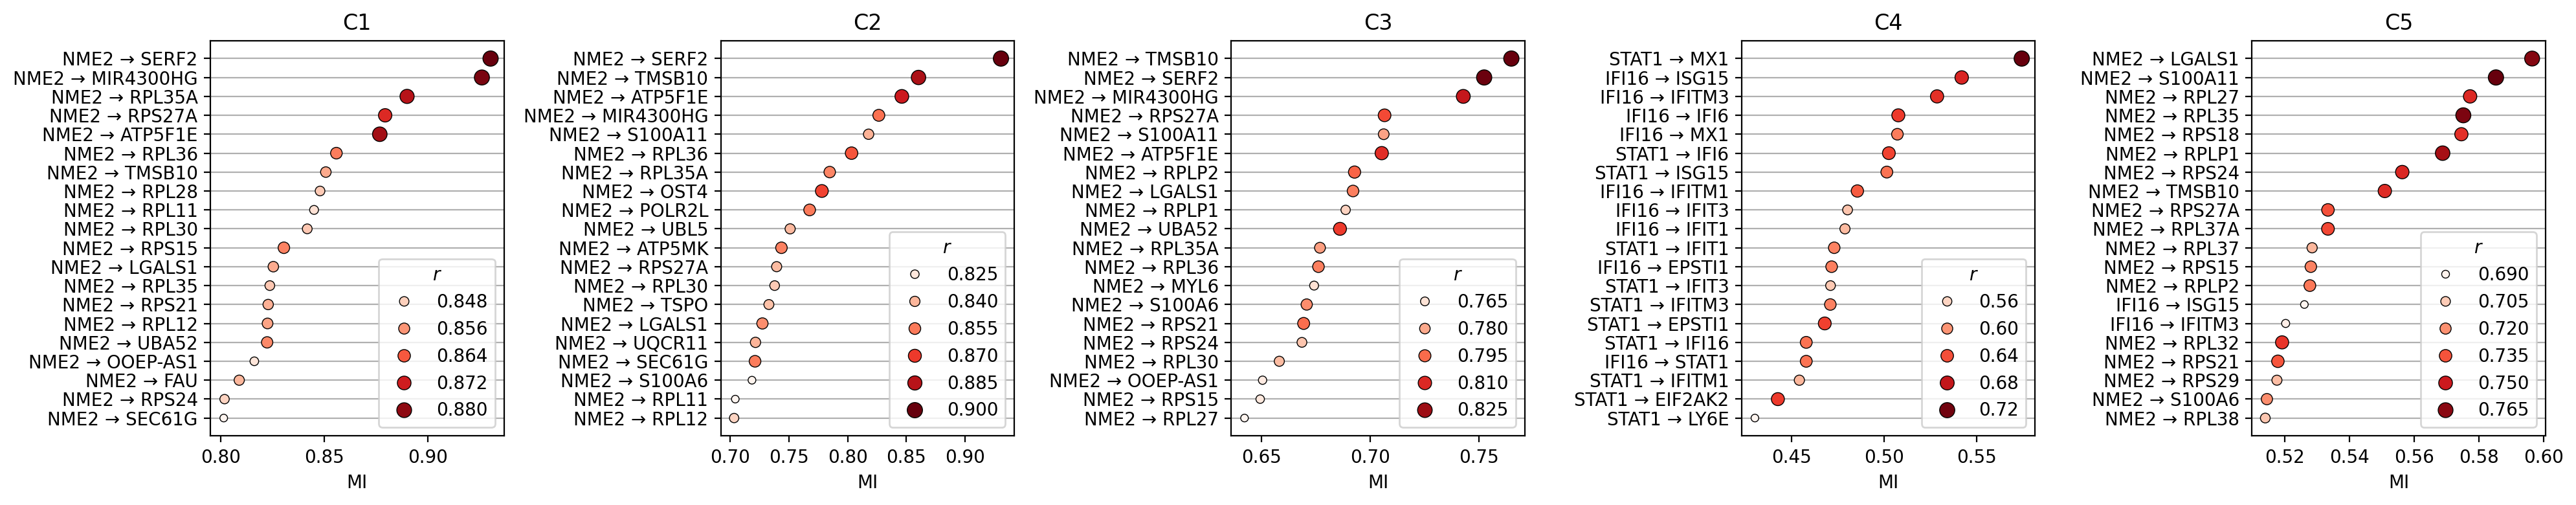

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 20, 4
fig, axes = plt.subplots(1, 5)

for i, (group_name, group) in enumerate(df.groupby('cluster')):
    group = group.sort_values('MI')
    group = group.tail(20)

    sns.scatterplot(
        data=group,
        x='MI',
        y='pair',
        hue='pearson',
        size='pearson',
        palette='Reds',
        ec='k',
        lw=0.5,
        ax=axes[i],
        zorder=5,
    )
    axes[i].set_ylabel("")
    axes[i].set_title(group_name)
    axes[i].invert_yaxis()
    axes[i].yaxis.grid(True, zorder=0)
    sns.move_legend(
        axes[i],
        loc='lower right',
        title=r'$r$', 
    )

plt.tight_layout()

# by cluster specific fold change
the above plot shows us that most cluster are dominanted by NMEF pairings.

In [10]:
%%time
foldchanges = []

for i, (group_name, group) in enumerate(df.groupby('cluster')):

    group_pairs = group['pair'].unique()
    out_group = df[(df['cluster'] != group_name) & df['pair'].isin(group_pairs)]

    # prepare the MI per pair
    out_group_mi = out_group.groupby(['source', 'target', 'pair'])['MI'].mean()
    group_mi = group[['source', 'target', 'pair', "MI"]]

    # print(f"{group_mi.shape=}")
    # print(f"{out_group_mi.shape=}")
    
    midf = pd.merge(
        group_mi,
        out_group_mi,
        how='left',
        left_on=['source', 'target', 'pair'],
        right_on=['source', 'target', 'pair'],
    ).fillna(0.0)

    # print(f"{midf.shape=}")

    # compute fold change
    midf['logfoldchange'] = np.log2(midf['MI_x'] / midf['MI_y'])    
    midf['cluster'] = group_name

    foldchanges.append(midf)

foldchanges = pd.concat(foldchanges)
print(f"{foldchanges.shape=}")
foldchanges.head()

foldchanges.shape=(1044554, 7)
CPU times: user 2.3 s, sys: 93 ms, total: 2.4 s
Wall time: 2.41 s


,source,target,pair,MI_x,MI_y,logfoldchange,cluster
0,AATF,ACSL4,AATF → ACSL4,0.1007,0.0000,inf,C1
1,AATF,ADAMTS1,AATF → ADAMTS1,0.0917,0.0803,0.191522,C1
2,AATF,ADAT1,AATF → ADAT1,0.1066,0.0000,inf,C1
3,AATF,ADIPOR1,AATF → ADIPOR1,0.1037,0.0000,inf,C1
4,AATF,ANP32E,AATF → ANP32E,0.0888,0.1116,-0.329705,C1


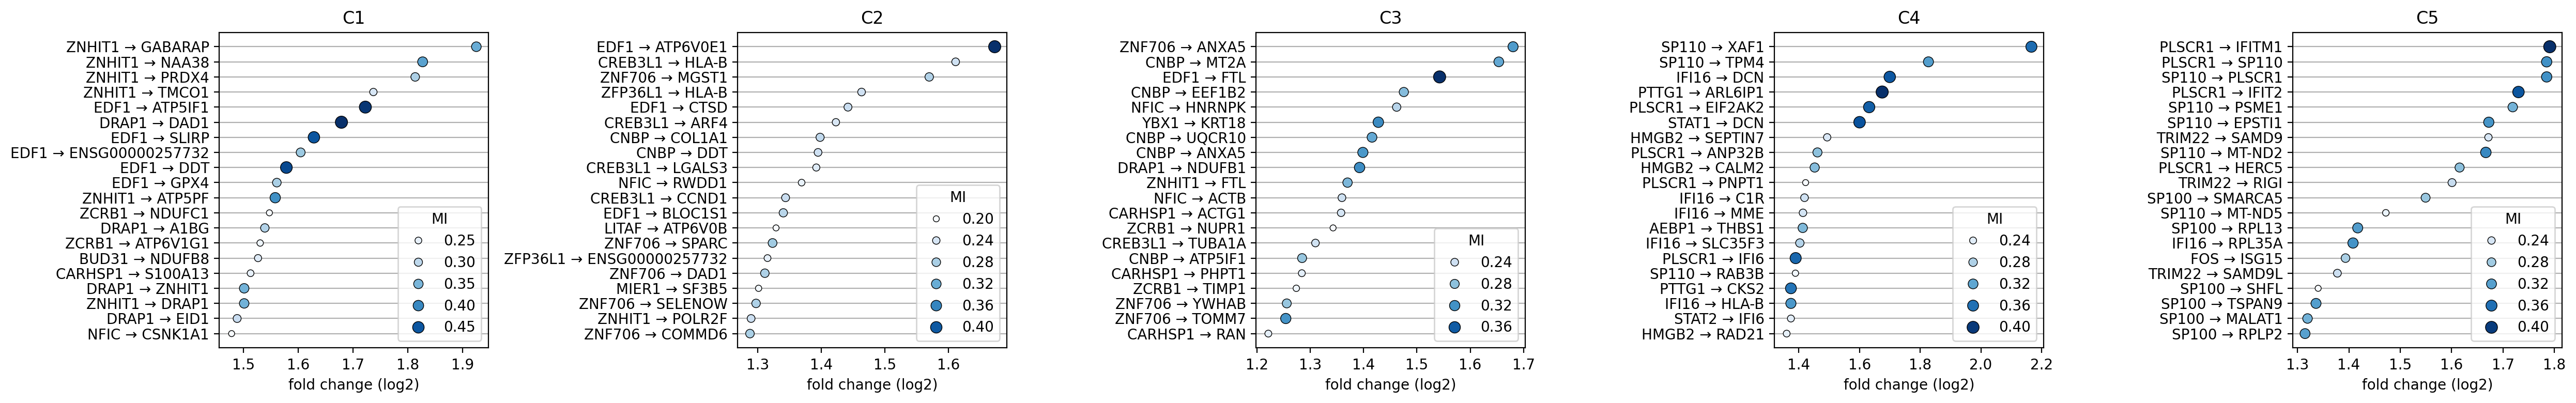

In [11]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 25, 4
fig, axes = plt.subplots(1, 5)

for i, (group_name, group) in enumerate(foldchanges.groupby('cluster')):
    group = group[np.isfinite(group['logfoldchange'])]
    group = group.sort_values('logfoldchange')
    
    group = group.tail(20)

    sns.scatterplot(
        data=group,
        x='logfoldchange',
        y='pair',
        hue='MI_x',
        size='MI_x',
        palette='Blues',
        ec='k',
        lw=0.5,
        ax=axes[i],
        zorder=5,
    )
    axes[i].set_ylabel("")
    axes[i].set_xlabel("fold change (log2)")
    axes[i].set_title(group_name)
    axes[i].invert_yaxis()
    axes[i].yaxis.grid(True, zorder=0)
    sns.move_legend(
        axes[i],
        loc='lower right',
        title='MI', 
    )

plt.tight_layout()

# GATA2

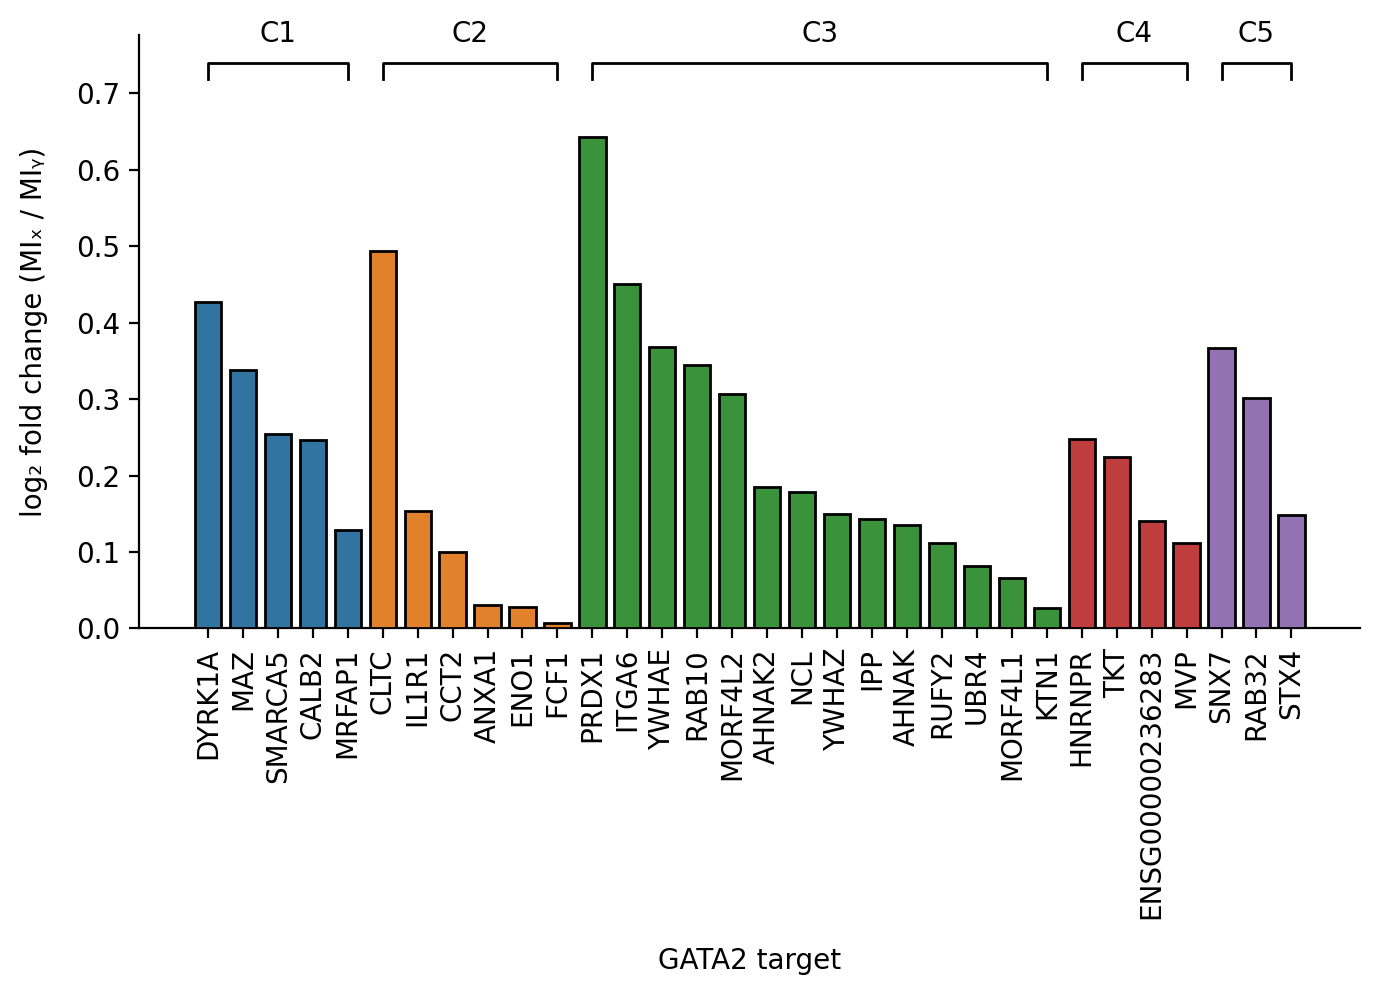

In [12]:
# Filter for source of interest
query = 'GATA2'
plot_df = foldchanges.copy()
plot_df = plot_df[plot_df['source'] == query]
plot_df = plot_df[np.isfinite(plot_df['logfoldchange'])]

# Find dominant cluster (highest positive log fold change per target)
dominant_cluster = (
    plot_df
    .sort_values('logfoldchange', ascending=False)
    .drop_duplicates('target')
    .set_index('target')['cluster']
)

# Add dominant cluster label to each row
plot_df['dominant_cluster'] = plot_df['target'].map(dominant_cluster)

# Keep only dominant cluster rows
plot_df = plot_df[plot_df['cluster'] == plot_df['dominant_cluster']].copy()

# Use dominant_cluster to control x-axis sorting
plot_df = (
    plot_df
    .sort_values(['dominant_cluster', 'logfoldchange'], ascending=[True, False])
)
plot_df['target'] = pd.Categorical(
    plot_df['target'],
    categories=plot_df['target'].unique(),
    ordered=True
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7, 5

ax = sns.barplot(
    data=plot_df,
    x='target',
    y='logfoldchange',
    hue='cluster',
    edgecolor='k',
    zorder=3,
    width=0.75,
    legend=False,
)

# Format
ax.set_ylabel("log₂ fold change (MIₓ / MIᵧ)", labelpad=10)
ax.set_xlabel(f"{query} target", labelpad=10)
plt.xticks(rotation=90)
ax.axhline(0, linestyle='--', color='gray', lw=1, zorder=1)
sns.despine()
plt.tight_layout()

# Get x-tick positions for each target
xticks = ax.get_xticks()
targets = plot_df['target'].tolist()
clusters = plot_df['dominant_cluster'].tolist()

# Group positions by cluster
from collections import defaultdict
cluster_xs = defaultdict(list)

for i, (target, cluster) in enumerate(zip(targets, clusters)):
    cluster_xs[cluster].append(xticks[i])

# Annotate bracket and label per cluster
ymax = plot_df['logfoldchange'].max()
y_bracket = ymax + 0.15 * abs(ymax)

for cluster, xs in cluster_xs.items():
    x0, x1 = min(xs), max(xs)
    xm = (x0 + x1) / 2

    # Draw bracket
    ax.plot([x0, x0, x1, x1], [y_bracket - 0.02, y_bracket, y_bracket, y_bracket - 0.02],
            color='black', lw=1)

    # Add label
    ax.text(xm, y_bracket + 0.02, cluster, ha='center', va='bottom', fontsize=10)



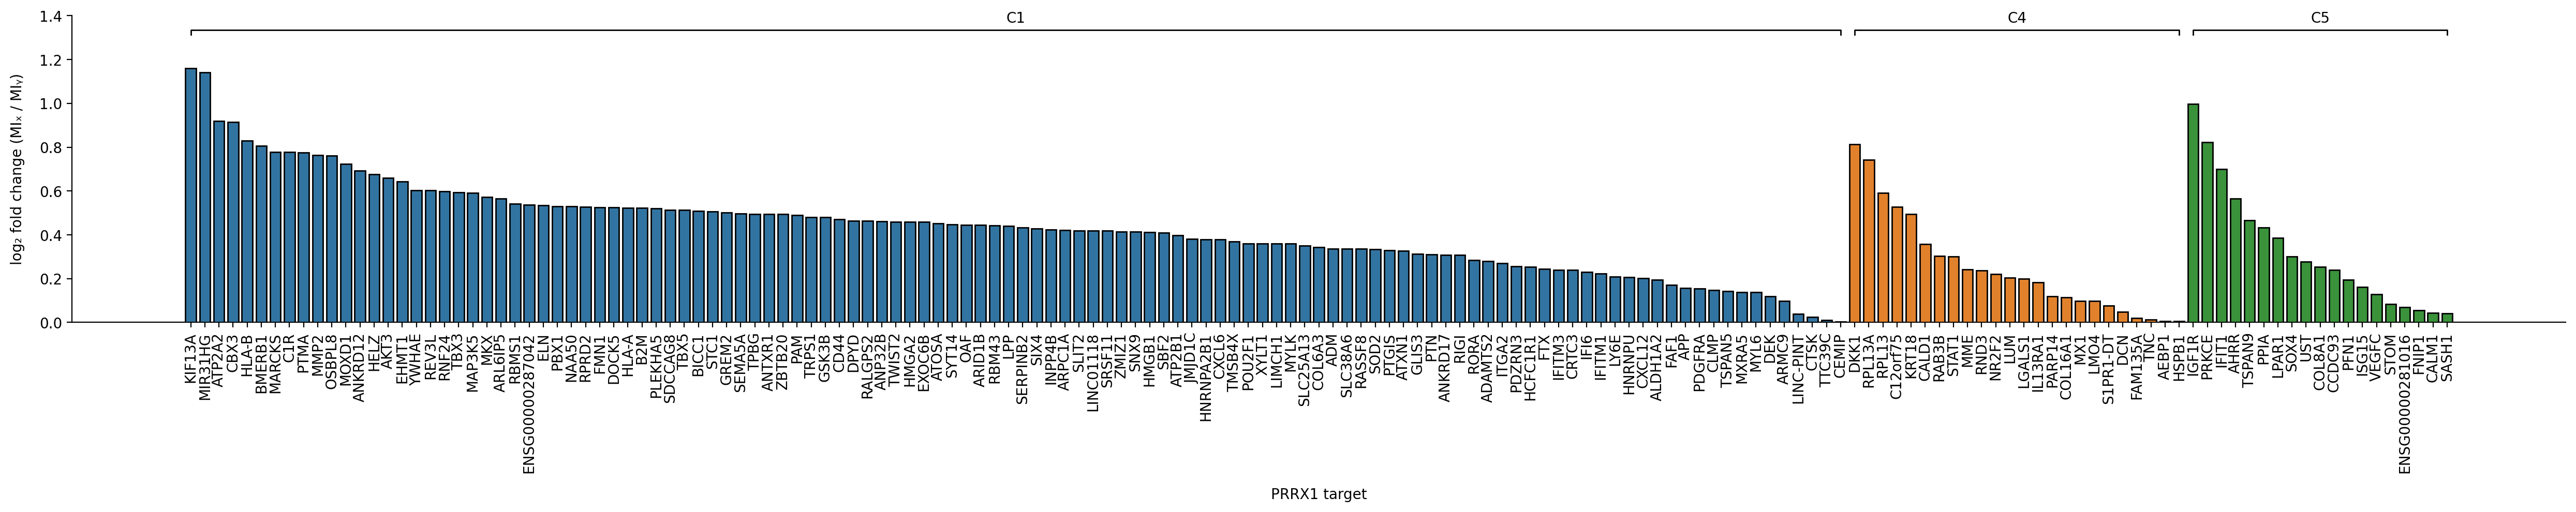

In [21]:
# Filter for source of interest
query = 'PRRX1'
plot_df = foldchanges.copy()
plot_df = plot_df[plot_df['source'] == query]
plot_df = plot_df[np.isfinite(plot_df['logfoldchange'])]

# Find dominant cluster (highest positive log fold change per target)
dominant_cluster = (
    plot_df
    .sort_values('logfoldchange', ascending=False)
    .drop_duplicates('target')
    .set_index('target')['cluster']
)

# Add dominant cluster label to each row
plot_df['dominant_cluster'] = plot_df['target'].map(dominant_cluster)

# Keep only dominant cluster rows
plot_df = plot_df[plot_df['cluster'] == plot_df['dominant_cluster']].copy()

# Use dominant_cluster to control x-axis sorting
plot_df = (
    plot_df
    .sort_values(['dominant_cluster', 'logfoldchange'], ascending=[True, False])
)
plot_df['target'] = pd.Categorical(
    plot_df['target'],
    categories=plot_df['target'].unique(),
    ordered=True
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 25, 5

ax = sns.barplot(
    data=plot_df,
    x='target',
    y='logfoldchange',
    hue='cluster',
    edgecolor='k',
    zorder=3,
    width=0.75,
    legend=False,
)

# Format
ax.set_ylabel("log₂ fold change (MIₓ / MIᵧ)", labelpad=10)
ax.set_xlabel(f"{query} target", labelpad=10)
plt.xticks(rotation=90)
ax.axhline(0, linestyle='--', color='gray', lw=1, zorder=1)
sns.despine()
plt.tight_layout()

# Get x-tick positions for each target
xticks = ax.get_xticks()
targets = plot_df['target'].tolist()
clusters = plot_df['dominant_cluster'].tolist()

# Group positions by cluster
from collections import defaultdict
cluster_xs = defaultdict(list)

for i, (target, cluster) in enumerate(zip(targets, clusters)):
    cluster_xs[cluster].append(xticks[i])

# Annotate bracket and label per cluster
ymax = plot_df['logfoldchange'].max()
y_bracket = ymax + 0.15 * abs(ymax)

for cluster, xs in cluster_xs.items():
    x0, x1 = min(xs), max(xs)
    xm = (x0 + x1) / 2

    # Draw bracket
    ax.plot([x0, x0, x1, x1], [y_bracket - 0.02, y_bracket, y_bracket, y_bracket - 0.02],
            color='black', lw=1)

    # Add label
    ax.text(xm, y_bracket + 0.02, cluster, ha='center', va='bottom', fontsize=10)



In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Interactions that change

In [ ]:
# Filter relevant clusters
df_sub = df[df['cluster'].isin(['C2', 'C3', 'C4', 'C5'])]
print(f"{df_sub.shape=}")

# Aggregate MI per source-target per cluster
agg = df_sub.pivot_table(
    index=['source', 'target'],
    columns='cluster',
    values='MI',
    aggfunc='first'  # or 'mean' if duplicates
).dropna().reset_index()

print(f"{agg.shape=}")

# Compute mean MI for experimental vs control clusters
agg['MI_exp'] = agg[['C2', 'C3']].mean(axis=1)
agg['MI_ctrl'] = agg[['C4', 'C5']].mean(axis=1)
agg['foldchange'] = np.log2(agg['MI_exp'] / agg['MI_ctrl'])
agg = agg.sort_values(by="foldchange", ascending=False)
print(agg.head(10).to_string())

In [ ]:
threshold = 0

plot_df = agg[agg['foldchange'] > threshold].copy()
plot_df = plot_df[plot_df['target'].isin(tf_list)]
print(f"raw: {plot_df.shape=}")

n_target = plot_df['target'].nunique()
n_source = plot_df['source'].nunique()

print(f"{n_target=}")
print(f"{n_source=}")

unique_genes = pd.unique(plot_df[['source', 'target']].values.ravel())
database = 'ontology'
alpha = 0.05
edf = gget.enrichr(unique_genes, database=database)
edf = edf[edf['adj_p_val'] <= alpha]
edf['genes'] = edf['overlapping_genes'].apply(
    lambda x: ",".join(x[:10]) + ("..." if len(x) > 10 else "")
)
print(edf[['path_name', 'adj_p_val', 'genes']].head(20).to_string(index=False))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = n_target / 5.5, n_source / 5.5
sns.scatterplot(
    data=plot_df,
    y='source',
    x='target',
    hue='foldchange',
    palette='afmhot',
    zorder=5,
    ec='k',
    lw=1,
    size='foldchange',
)

plt.xticks(rotation=90)
plt.grid(True)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title="fold change",
    bbox_to_anchor=(1.35, 0.5)
)
plt.title("TF - TF")

plt.margins(y=0.1, x=0.01)

In [ ]:
threshold = 1.

plot_df = agg[agg['foldchange'] > threshold].copy()
plot_df = plot_df[plot_df['source'] != 'NME2']
print(f"raw: {plot_df.shape=}")

n_target = plot_df['target'].nunique()
n_source = plot_df['source'].nunique()

print(f"{n_target=}")
print(f"{n_source=}")

unique_genes = pd.unique(plot_df[['source', 'target']].values.ravel())
database = 'ontology'
# database = 'celltypes'
alpha = 0.05
edf = gget.enrichr(unique_genes, database=database)
edf = edf[edf['adj_p_val'] <= alpha]
edf['genes'] = edf['overlapping_genes'].apply(
    lambda x: ",".join(x[:10]) + ("..." if len(x) > 10 else "")
)
print(edf[['path_name', 'adj_p_val', 'genes']].head(20).to_string(index=False))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = n_target / 5.5, n_source / 5.5
sns.scatterplot(
    data=plot_df,
    y='source',
    x='target',
    zorder=5,
    ec='k',
    hue='foldchange',
    palette='afmhot',
    lw=1,
    size='foldchange',
)

plt.xticks(rotation=90)
plt.grid(True)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title="fold change",
    bbox_to_anchor=(1.05, 0.5)
)
plt.title("TF - Gene")

plt.margins(y=0.1, x=0.01)

In [ ]:
break

In [ ]:
threshold = 0.

for group_name, group in mdf.groupby(['source', 'category',]):
    source, category = group_name

    gene_list = group['gene_name'].unique()

    plot_df = agg.copy()
    print(f"raw: {plot_df.shape=}")
    plot_df = plot_df[plot_df['target'].isin(gene_list)]
    plot_df = plot_df[plot_df['foldchange'] > threshold]

    n_target = plot_df['target'].nunique()
    n_source = plot_df['source'].nunique()
    
    print(f"{n_target=}")
    print(f"{n_source=}")

    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = n_target / 5.5, n_source / 5.5
    sns.scatterplot(
        data=plot_df,
        y='source',
        x='target',
        hue='foldchange',
        palette='afmhot',
        zorder=5,
        ec='k',
        lw=1,
        size='foldchange',
    )

    plt.xticks(rotation=90)
    plt.grid(True)
    sns.move_legend(
        plt.gca(),
        loc='center right',
        title="fold change",
        bbox_to_anchor=(1.35, 0.5)
    )
    plt.title(f"{category} ({source})")
    plt.margins(y=0.1, x=0.05)
    plt.show()


In [ ]:
break

In [ ]:
# Filter once
df_sub = df[df['cluster'].isin(['C2', 'C3', 'C4', 'C5'])]
df_sub = df_sub[df_sub['sig']]

mi_diffs = []
groups = df_sub.groupby(['source', 'target'])

for (s, t), group in tqdm(groups, desc="Computing ΔMI"):
    exp = group[group['cluster'].isin(['C2', 'C3'])]['MI']
    ctrl = group[group['cluster'].isin(['C4', 'C5'])]['MI']
    if len(exp) >= 2 and len(ctrl) >= 2:
        stat, pval = ttest_ind(exp, ctrl, equal_var=False)
        mi_diffs.append((s, t, exp.mean(), ctrl.mean(), exp.mean() - ctrl.mean(), pval))

diff_df = pd.DataFrame(mi_diffs, columns=['source', 'target', 'MI_exp', 'MI_ctrl', 'MI_diff', 'p_value'])
diff_df

In [ ]:
break

# TF specific wiring (source)

In [ ]:
queries = ['GATA2', 'SOX9', 'PRRX1', 'TWIST2',]
fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=300)

for ax, query in zip(axes.flat, queries):
    pdf = df[df['source'] == query]
    pdf = pdf[pdf['sig']]

    sns.boxplot(
        data=pdf,
        x='cluster',
        y='MI',
        hue='cluster',
        ax=ax,
        showfliers=False,
        linecolor='k',
        width=0.5,
        linewidth=1,
        capprops={'lw': 0},
    )

    ax.set_title(query)
    ax.set_xlabel("")
    ax.set_ylabel("Mean MI")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# cluster specific interactions for each TF

In [ ]:
tf_recipe = ['GATA2','FOS', 'STAT5A', 'REL',]
n_top = 25 # top targets per TF
pdf = df.copy()
pdf = pdf[pdf['source'].isin(tf_recipe)]

pdf = pdf[pdf['sig']]
print(pdf['source'].unique())

for cluster, group in pdf.groupby('cluster'):
    print(f"{cluster} {group.shape}")
    group = group.sort_values('MI', ascending=False)

    fig, axes = plt.subplots(2, 2, figsize=(6, 9), sharey=False)
    axes = axes.flatten()

    for i, tf in enumerate(tf_recipe[:4]):  # first 4 TFs in 2x2 grid
        tf_group = group[group['source'] == tf].nlargest(n_top, 'MI')
        sns.scatterplot(
            data=tf_group,
            y='target',
            x='MI',
            ax=axes[i],
            hue='pearson',
            size='pearson',
            palette='Reds',
            edgecolor='k',
            lw=0.75,
            zorder=5,
            legend=False,
        )
        axes[i].set_title(tf)
        axes[i].grid(True)
        axes[i].set_ylabel("")
        axes[i].set_ymargin(0.1)
        axes[i].set_xmargin(0.1)
    
    plt.suptitle(f"Top TF Targets — Cluster {cluster}")
    plt.tight_layout()
    plt.show()
    # break  # remove if looping over all clusters



In [ ]:
break

In [ ]:
fpath = "../../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

In [ ]:
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

pdf = df.copy()
pdf = pdf[pdf['source'].isin(tf_recipe)]

pdf = pdf[pdf['sig']]
pdf = pdf[pdf['target'].isin(tf_list)]
print(pdf['source'].unique())

for cluster, group in pdf.groupby('cluster'):
    print(f"{cluster} {group.shape}")
    group = group.sort_values('MI', ascending=False)

    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = (group['target'].nunique() / 5), (group['source'].nunique() / 3)

    sns.scatterplot(
        data=group,
        x='target',
        y='source',
        size='pearson',
        hue='pearson',
        palette='bwr',
        ec='k',
        vmin=0,
        vmax=1,
        lw=1,
        legend=False,
        zorder=5
    )

    plt.grid(True)
    plt.title(cluster)
    plt.xticks(rotation=90)
    plt.margins(y=0.5)


    plt.show()

In [ ]:
# load marker sets
fpath = "../../../resources/clean_marker_genes.csv"
gdf = pd.read_csv(fpath)
gdf.head()

In [ ]:
gdf['category'].value_counts()

In [ ]:
gdf['source'].value_counts()

In [ ]:
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
cluster = 'C3'
marker_category = 'hematopoietic'
marker_source = 'panglao'


pdf = df.copy()
pdf = pdf[pdf['source'].isin(tf_recipe)]
pdf = pdf[pdf['sig']]
pdf = pdf[~pdf['target'].str.startswith('RP')]
pdf = pdf[~pdf['target'].str.startswith('MT')]

gene_list = gdf[(gdf['category'] == marker_category) & (gdf['source'] == marker_source)]['gene_name'].unique()
print(f"Marker Genes: {marker_category} from {marker_source} ({len(gene_list)})")

pdf = pdf[pdf['target'].isin(gene_list)]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (pdf['target'].nunique() / 5), (pdf['source'].nunique() / 3)

sns.scatterplot(
    data=pdf,
    x='target',
    y='source',
    ec='k',
    s=50,
    color='lightgrey',
    lw=1,
    legend=False,
    zorder=2
)

sns.scatterplot(
    data=pdf[pdf['cluster'] == cluster],
    x='target',
    y='source',
    ec='k',
    s=50,
    color='r',
    # hue='pearson',
    # palette='Reds',
    lw=1,
    legend=False,
    zorder=4
)


plt.grid(True)
plt.xticks(rotation=90)
plt.margins(y=0.5, x=0.05)
plt.title(f"{cluster} ({marker_category} {marker_source})")


In [ ]:
break

# Networks

In [ ]:
%%time 

graphs = {}
centralities = []

for i, (cluster, group) in enumerate(df.groupby('cluster')):
    print(f"\nProcessing cluster: {cluster}")

    t0 = time.time()
    G = nx.from_pandas_edgelist(group, edge_attr=True, create_using=nx.DiGraph())
    t1 = time.time()
    print(f"  Graph construction time: {t1 - t0:.3f}s")

    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    t2 = time.time()
    print(f"  Component filtering time: {t2 - t1:.3f}s")

    graphs[cluster] = G.copy()

    ec = nx.eigenvector_centrality(G, max_iter=1000, weight='MI')
    t3 = time.time()
    print(f"  Eigenvector centrality time: {t3 - t2:.3f}s")

    ec_df = pd.DataFrame.from_dict(ec, orient='index', columns=['eigenvector_centrality'])
    ec_df.index.name = 'gene'
    ec_df.reset_index(inplace=True)
    ec_df['cluster'] = cluster
    centralities.append(ec_df)

centralities = pd.concat(centralities)
print(centralities.head().to_string(index=False))

In [ ]:
# Select top n genes per cluster
n = 25

pdf = centralities.copy()
pdf = pdf[~pdf['gene'].str.startswith('RP')]
pdf = pdf[~pdf['gene'].str.startswith('MT')]

top_genes = (
    pdf.sort_values(by='eigenvector_centrality', ascending=False)
          .groupby('cluster')
          .head(n)
          .sort_values(by=['cluster', 'eigenvector_centrality'], ascending=[True, False])
)


# Plot
clusters = top_genes['cluster'].unique()
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 25, 8

fig, axes = plt.subplots(1, len(clusters),sharey=False)

if len(clusters) == 1:
    axes = [axes]

for ax, cluster in zip(axes, clusters):
    data = top_genes[top_genes['cluster'] == cluster]
    ax.barh(
        data['gene'], 
        data['eigenvector_centrality'], 
        color='steelblue',
        ec='k',
        height=0.5,
    )
    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("Eigenvector Centrality")
    ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Select top n genes per cluster
n = 15
database = 'ontology'
# database = 'TRRUST_Transcription_Factors_2019'

pdf = centralities.copy()
pdf = pdf[~pdf['gene'].str.startswith('RP')]
pdf = pdf[~pdf['gene'].str.startswith('MT')]

for i, (cluster, group) in enumerate(pdf.groupby('cluster')):
    group = group.sort_values('eigenvector_centrality', ascending=False).head(n)

    edf = gget.enrichr(group['gene'].values, database=database)
    edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
    edf = edf[['path_name', 'adj_p_val', 'genes']]

    print(f"Cluster: {cluster}")
    print(edf.head(10).to_string(index=False))
    print()

plt.tight_layout()

# Plot networks

In [ ]:
nodes = 20
for cluster, G in graphs.items():
    print(f"{cluster} {G}")
    # Top 20 nodes by degree
    top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:nodes]
    print(top_nodes[:10])
    # break
    # nodes = [n for n, _ in top_nodes]
    # subG = G.subgraph(nodes).copy()
    
    # # Layout
    # pos = nx.spring_layout(subG, seed=42)
    
    # # Node properties
    # degrees = dict(subG.degree)
    # node_sizes = [300 + len(n)*2 for n in subG.nodes]

    # # Centrality (e.g., eigenvector)
    # ec = nx.eigenvector_centrality(subG, max_iter=1000, weight='MI')
    # node_color = [ec[n] for n in subG.nodes]
    
    # # Edge properties
    # edge_weights = [subG[u][v].get("MI", 0.1)*5 for u, v in subG.edges]
    
    # # Draw
    # plt.figure(figsize=(8, 8))
    # nx.draw_networkx_nodes(
    #     subG, 
    #     pos, 
    #     node_size=node_sizes,
    #     node_color=node_color, 
    #     edgecolors='k', 
    #     linewidths=0.75,
    #     cmap='vlag',
    # )
    
    # nx.draw_networkx_edges(
    #     subG, 
    #     pos, 
    #     width=edge_weights, 
    #     alpha=0.6,
    #     arrows=True,
    #     arrowsize=5  # default ~20, so 10 is smaller
    # )
    
    # nx.draw_networkx_labels(subG, pos, font_size=4, font_color='black')
    
    # plt.axis('off')
    # plt.title(f"{cluster} (Top 20 Nodes by Degree)", fontsize=12)
    # plt.tight_layout()
    # plt.show()
    # # break
    
    

In [ ]:
break

In [ ]:
# Select graph
G = graphs['C3']

# Define subgraph nodes (e.g., top 20 by degree)
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]
nodes = [n for n, _ in top_nodes]
subG = G.subgraph(nodes)

# Plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, with_labels=True, node_size=300, font_size=8)
plt.title("Subgraph of C3 (Top 20 Nodes by Degree)")
plt.show()


In [ ]:
nx.draw_network(graphs['C3'])